**Name:** Ryan Taylor \
**Class:** CSCA 5622 \
**Date:** 05-01-2025

### : Init

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# \[ Abstract \]

## Objective
Create a model that can predict the outcome of a League of Legends match based only on each team's champions.

#### Helpful Context/Information
In League of Legends, a match consists of **two 5-player teams** where each player selects a 'champion'. All players must select a **unique** champion (i.e. No 2 players can select the same champion). A match always results in **one** of the teams' victory; there are no ties. Thus, a match is described as **2 teams** of **5 champions** (10 unique champions total), with **1 team as the winner**.

Teams are **symetric**, meaning the designation of "Team A" or "Team B" is completely arbitrary, all differences in team performance is exclusively due to player action.

## Data
### Features
- Team A's champions.
- Team B's champions.

A champion is a **categorical** value that, abstractly, has 170 possible values (there are 170 available champions to chose from in the game); a champion cannot be meaningfully represented numerically.

All features are **categorical**.

### Target
- Winning team (A or B).

The target is a **binary classification** representing which team (out of two) won.

### Collection
The data was collected using a hand-written program. This program utilizes the League of Legends REST API to request/recieve data via http requests.

### Contents
The data collected consists of **363** League of Legends matches, each containing both teams' champion composition and the outcome of the match.

# \[ Data \]

The collected data is a contained in `data/matches.csv`.

In [93]:
rawdata = pd.read_csv('data/matches.csv')

## Overview
The data contains 726 rows and 342 columns.

In [94]:
rawdata

,ally_aatrox,ally_ahri,ally_akali,ally_akshan,ally_alistar,ally_ambessa,ally_amumu,ally_anivia,ally_annie,ally_aphelios,...,opponent_yuumi,opponent_zac,opponent_zed,opponent_zeri,opponent_ziggs,opponent_zilean,opponent_zoe,opponent_zyra,match_id,win
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,NA1_5273141414,0
1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,NA1_5273141414,1
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,NA1_5273127984,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,NA1_5273127984,0
4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,NA1_5272576309,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,NA1_5262162307,0
722,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,NA1_5262098036,0
723,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,NA1_5262098036,1
724,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,NA1_5261325631,1


### Column Definitions

| # | Name | Type | Meaning |
| :- | :- | :-| :- |
| 1..170 | ally\_*\<champion\>* | int | Whether or not *\<champion\>* is present on the ally team (1 = True, 0 = False). |
| 171..340 | opponent\_*\<champion\>* | int | Whether or not *\<champion\>* is present on the opponent team (1 = True, 0 = False). |
| 341 | match_id | string | This match's ID. |
| 342 | win | int | Whether or not the ally team won (1 = True, 0 = False). |


### Row Definition
Each row represents a match viewed from one team. Each 2 consecutive rows depict the same match viewed from both teams.

Even rows are **exactly** their previous row with:
- Columns 1..170 swapped with 171..340 (to effectively swap the champions on each team).
- The `win` column inverted (`1` → `0`; `0` → `1`)

This 2-row representation is to account for the fact that there is no functional difference between a win for A against B and a loss for B against A.

## Cleaning

Because I wrote the data collection program myself, much of the data processing was already done by that program. \
However, there are still a few small issues with the output data:
- The data type for each column is `int` when they are functionally `bool`.
- There are a few rows where there are not **exactly 10** `1` values in columns 1..340. This would indicate that there were not exactly 10 champions in a match, which is not possible, and such rows are invalid data.

The `match_id` column is not useful as training data but will be used for cross validation grouping.

In [95]:
matchids = rawdata['match_id']
# convert columns to 'bool' except for match_id
df = rawdata.drop(columns='match_id').astype(bool)
df['match_id'] = matchids
print("Converted all values to bool.")

# discard rows where there are not exactly 10 champions
df = df[df.drop(columns=['win', 'match_id']).sum(axis=1) == 10]
print (f"Dropped {len(rawdata) - len(df)} invalid rows.")

Converted all values to bool.
Dropped 6 invalid rows.


In [96]:
assert rawdata.iloc[0::2]['match_id'].is_unique

for i in np.arange(1, len(df)-1, 2):
    assert [ally for ally in df.iloc[i][0:170].iloc()] == [opp for opp in df.iloc[i-1][170:340].iloc()]

assert (df['win'].sum() == len(df)/2)

# \[ Exploratory Data Analysis \]

> It is important to keep in mind that every **even row** contains exactly the same information/match as the previous row when doing EDA.

All features in this dataset are **binary**. Most numerical EDA analysis methods are **not applicable** to this dataset (histograms, correlation, etc.).

### : Init

In [97]:
target = 'win'
grouping = 'match_id'
non_data = [target, grouping]
feat_count = len(df.columns) - 1
ally_section = range(0, int(feat_count/2))
opponent_section = range(int(feat_count/2), feat_count)

## Sparsity
As stated, due to the nature of the data, each row has *exactly* 10 out of 340 `True` features, while the rest are `False`. This is **considerably sparse** by row, and our prediction model must use an algorithm that can handle this sparsity well.

In [98]:
assert all([x == 10 for x in df.drop(columns=non_data).sum(axis=1)])
print(f"Fixed row sparsity: {10/feat_count}")

Fixed row sparsity: 0.02932551319648094


## Feature Distribution

In [99]:
totals = df.iloc[:, ally_section].sum()
totals.index = totals.index.str.replace('^ally_', '', regex=True)
totals = totals.sort_values()

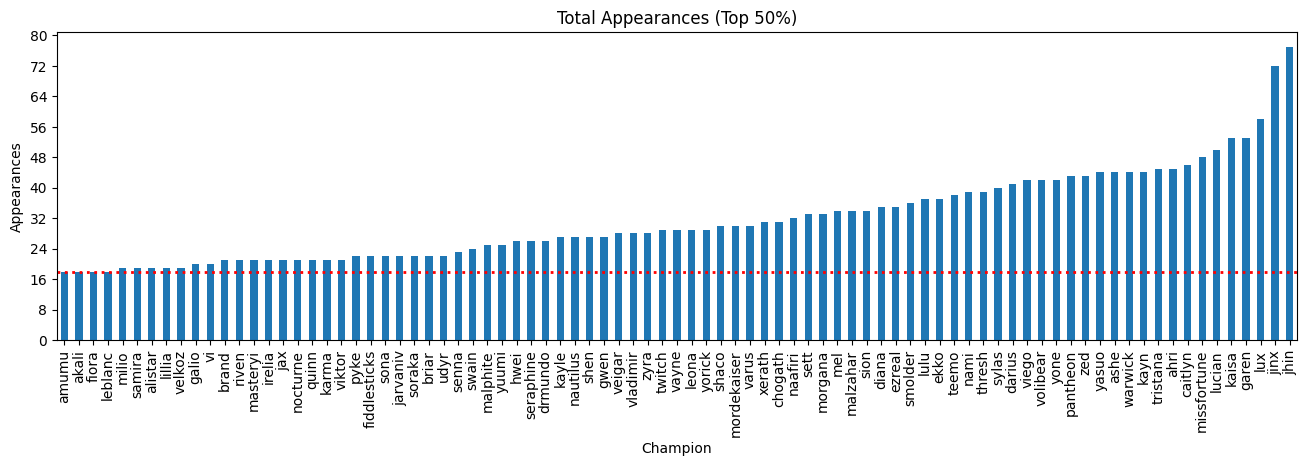

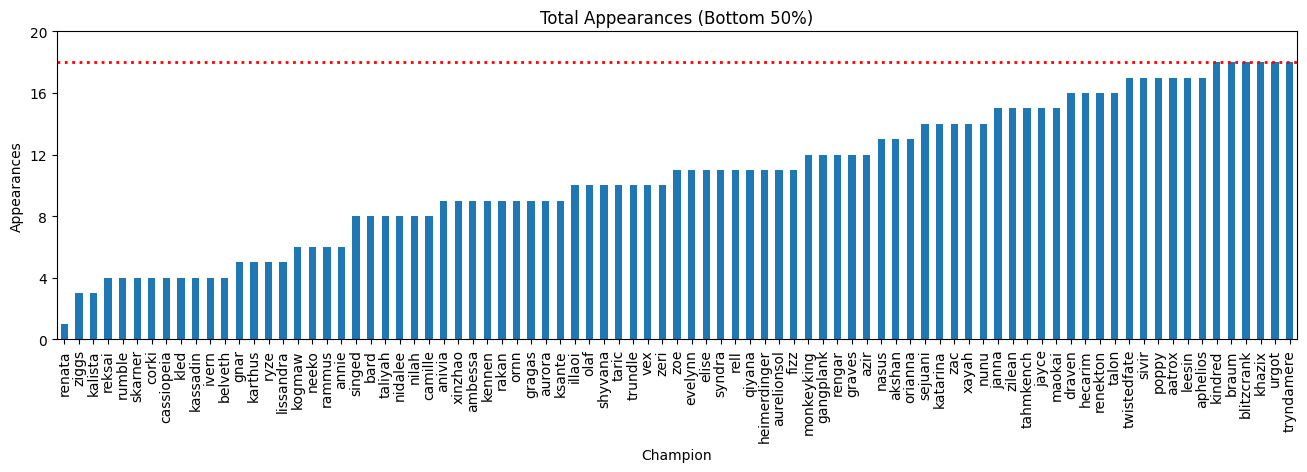

In [100]:
def champ_appearance_plot(data):
    midpoint = int(len(data)/2)
    midfreq = data.iloc[midpoint]
    data[midpoint:].plot(kind='bar', figsize=(16,4), title='Total Appearances (Top 50%)')
    plt.axhline(y=midfreq, color='red', linestyle=':', linewidth=2)
    plt.xlabel('Champion')
    plt.ylabel('Appearances')
    plt.yticks(np.arange(0, 88, 8))
    plt.show()
    data[:midpoint].plot(kind='bar', figsize=(16,4), title='Total Appearances (Bottom 50%)')
    plt.axhline(y=midfreq, color='red', linestyle=':', linewidth=2)
    plt.xlabel('Champion')
    plt.ylabel('Appearances')
    plt.yticks(np.arange(0, 24, 4))
    plt.show()

champ_appearance_plot(totals)

There is an observable uneven feature distribution.

There are a few champions that appear a very small amount of times (<= 3), particularly `renata`, `ziggs`, and `kalista`; `renata` is only present in a single match.

There are also a few champions that appear far more than average, particularly `jhin`, `jinx`, and `lux`.

In [157]:
sparse_champions = totals[-5:]
dense_champions = totals[:5]

## Univariate Feature Importance (Chi^2)

In [158]:
from sklearn.feature_selection import chi2, mutual_info_classif

feat_df = df.iloc[:, ally_section]
feat_df.columns = feat_df.columns.str.replace('^ally_', '', regex=True)

X = feat_df
y = df[target].astype(int)

# Compute univariate scores
chi2_scores, chi2_p = chi2(X, y)
feat_stats = pd.DataFrame({
    'feature': X.columns,
    'chi2': chi2_scores,
}).set_index('feature')

In [159]:
def feature_imp_plot(data, label):
    data = data.sort_values(by=label)[label]
    midpoint = int(len(data)/2)
    midfreq = data.iloc[midpoint]
    data[midpoint:].plot(color='green', kind='bar', figsize=(16,4), title=f'{label} (Top 50%)')
    plt.axhline(y=midfreq, color='red', linestyle=':', linewidth=2)
    plt.xlabel('Champion')
    plt.ylabel(label)
    plt.yticks()
    plt.show()
    data[:midpoint].plot(color='green', kind='bar', figsize=(16,4), title=f'{label} (Bottom 50%)')
    plt.axhline(y=midfreq, color='red', linestyle=':', linewidth=2)
    plt.xlabel('Champion')
    plt.ylabel(label)
    plt.yticks()
    plt.show()

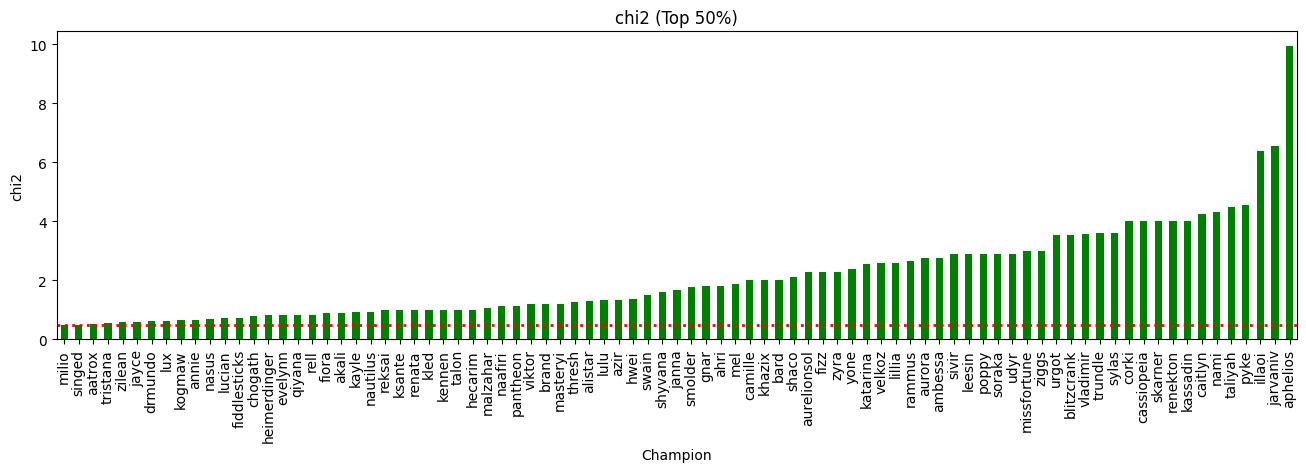

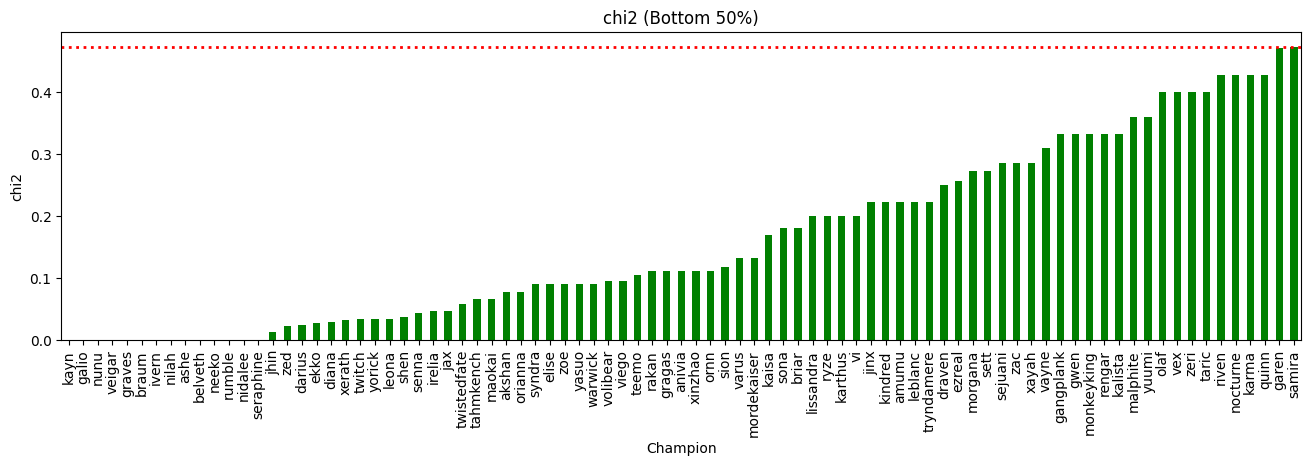

In [160]:
feature_imp_plot(feat_stats, 'chi2')

According to chi^2 univariate analysis, there are a few champions with 0 influence, aswell as a select few with extremely high influence (namely `aphelios`, `jarvaniv`, and `illaoi`).

However, univariate analysis only evaluates each feature independently; it does not evaluate complex or multi-feature relationships. While this univariate analysis should be noted, it is expected that more complex relationships exist and will be found during model creation.

In [161]:
high_uni_importance = feat_stats.sort_values(by='chi2')['chi2'][-5:]
high_uni_importance

feature
taliyah     4.500000
pyke        4.545455
illaoi      6.400000
jarvaniv    6.545455
aphelios    9.941176
Name: chi2, dtype: float64

## Low Sample Size
Due to API limits and time constraints, 363 matches is the most I could retrieve with my program. This is a **considerably low amount of data** given the project objective/features. I presume that this will be the **primary bottleneck** of model performance.

# \[ Models / Analysis \]

### Expectations

Based on my own knowledge on League of Legends and it's game design, it is expected that:
- There are many **multi-feature**, and/or complex relationships.
- 0.65-0.70 is around the **maximum accuracy** a model can achieve given this type of data, even if given a very large dataset. \
  *There are many factors outside of teams' champion composition that influence the outcome of a match of League of Legends.*

Also, as mentioned before, the **sample size is very low**, thus I realistically do not expect to be able to train a very well performing model.

### Model Criteria

The learning methods/model(s) used to achieve this objective should:
- be **classifiers** (not **regressors**).
- capture complex and multi-feature relationships.
- gracefully handle a large amount of categorical features.
- gracefully handle sparse data.
- gracefully handle uneven feature distribution.

From these criteria, **tree ensemble** methods seem to be the best fit. The primary learning methods used to create this model will be **gradient boosting** and **random forest**.

Other methods like **logistic regression** and **linear svm** may technically work, but they would not be a great fit for the data because they are **linear** models, and would not capture complex relationships as well and as easily as decision trees.

### Evaluation Method

Models will be trained to maximize **roc-auc** instead of accuracy to avoid overfitting, which decision-tree-based models are prone to. Model test performance will be evaluated based on **cross-validation mean accuracy**.

Cross validation and test/train data splitting will be **grouped** based on match (i.e. every 2 rows will be treated as a single data entry because they represent the same match).

In [166]:
from sklearn.model_selection import train_test_split, cross_validate, GroupKFold
this_random_state = 401
X = df.drop(columns=non_data)
y = df[target]
X_train, X_test, y_train, y_test = (X[70:], X[:70], y[70:], y[:70])

# create grouping based on match; every 2 rows treated as 1 entry.
groups = df['match_id']
groups_train = groups[70:]
group_cv = GroupKFold(n_splits=5)

In [109]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, mean_squared_error

# This class streamlines evaluating model performance.
class ModelEvaluator:
    def __init__(self, base_model, X, y):
        self.model = base_model
        self.X = X
        self.y = y
        assert self.model._estimator_type == 'classifier'

    def cross_val_score(self, scoring=None, n_jobs=None, return_train_score=True):
        if scoring is None:
            scoring = ['accuracy', 'f1', 'roc_auc']
        elif isinstance(scoring, str):
            scoring = [scoring]
        cv_results = cross_validate(
            self.model,
            self.X,
            self.y,
            groups=groups,
            cv=group_cv,
            scoring=scoring,
            n_jobs=n_jobs,
            return_train_score=return_train_score
        )
        summary = {}
        for metric in scoring:
            key_test = f'test_{metric}'
            summary[f'{metric}_mean'] = cv_results[key_test].mean()
            summary[f'{metric}_std'] = cv_results[key_test].std()
            if return_train_score:
                key_train = f'train_{metric}'
                summary[f'train_{metric}_mean'] = cv_results[key_train].mean()
                summary[f'train_{metric}_std'] = cv_results[key_train].std()
        return summary

def print_eval(evaluator):
    cv = evaluator.cross_val_score()
    print("---- SCORES ----")
    print(f"ACCURACY : {round(cv['accuracy_mean'], 3)} :: {round(cv['accuracy_std'], 3)} std")
    print(f"ROC_AUC  : {round(cv['roc_auc_mean'], 3)} :: {round(cv['roc_auc_std'], 3)} std")
    print(f"F1       : {round(cv['f1_mean'], 3)} :: {round(cv['f1_std'], 3)} std")
    print("----------------")

## Baseline Model
`DummyClassifier` from `sklearn` provides a baseline model performance.

In [170]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy='stratified', random_state=this_random_state)
baseline_eval = ModelEvaluator(baseline, X, y)
print_eval(baseline_eval)

---- SCORES ----
ACCURACY : 0.492 :: 0.032 std
ROC_AUC  : 0.492 :: 0.032 std
F1       : 0.499 :: 0.032 std
----------------


The baseline accuracy is **~0.5**, which is exactly what is to be expected from a binary target with an even distribution.

## Gradient Boosting

`GradientBoostingClassifier` from `sklearn` will be used as a base model for gradient boosting. `GridSearchCV` will be used to search for fitting hyper-parameters.

In [171]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# base model
gbm = GradientBoostingClassifier(random_state=this_random_state, validation_fraction=0.1)

# parameter search grid
param_grid = {
    'loss': ['log_loss', 'exponential'],
    'learning_rate': [0.1, 0.3, 0.5],
    'min_samples_leaf': [2, 5, 10],
    'max_depth': [2, 3, 5],
    'max_features': [None, 'sqrt', 'log2'],
}

grid = GridSearchCV(
    estimator=gbm,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=group_cv,              
    n_jobs=-1,      
    verbose=2,      
    refit=True        
)

grid.fit(X_train, y_train, groups=groups_train)



Fitting 5 folds for each of 162 candidates, totalling 810 fits


GridSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=GradientBoostingClassifier(random_state=401), n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.3, 0.5],
                         'loss': ['log_loss', 'exponential'],
                         'max_depth': [2, 3, 5],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [2, 5, 10]},
             scoring='roc_auc', verbose=2)

In [172]:
print("BEST AUC    :", grid.best_score_)
print("BEST PARAMS :", grid.best_params_)

best_gbm = grid.best_estimator_
y_pred_proba = best_gbm.predict_proba(X_test)[:,1]
y_pred = best_gbm.predict(X_test)
y_pred_train = best_gbm.predict(X_train)

from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
print("TEST ROC-AUC   :", roc_auc_score(y_test, y_pred_proba))
print("TEST ACCURACY  :", accuracy_score(y_test, y_pred))
print("TRAIN ACCURACY :", accuracy_score(y_train, y_pred_train))
print(classification_report(y_test, y_pred))
gbm_eval = ModelEvaluator(best_gbm, X, y)
print_eval(gbm_eval)

BEST AUC    : 0.5877396449704142
BEST PARAMS : {'learning_rate': 0.3, 'loss': 'log_loss', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2}
TEST ROC-AUC   : 0.5387755102040817
TEST ACCURACY  : 0.5714285714285714
TRAIN ACCURACY : 0.9738461538461538
              precision    recall  f1-score   support

       False       0.57      0.57      0.57        35
        True       0.57      0.57      0.57        35

    accuracy                           0.57        70
   macro avg       0.57      0.57      0.57        70
weighted avg       0.57      0.57      0.57        70

---- SCORES ----
ACCURACY : 0.532 :: 0.056 std
ROC_AUC  : 0.55 :: 0.057 std
F1       : 0.525 :: 0.052 std
----------------


The optimal gradient boosting model had a reported testing accuracy of **0.57** and a cross-validation mean accuracy of **0.53**. This is evidence that this model generally performs **very slightly** better than the baseline.

### Feature Importance

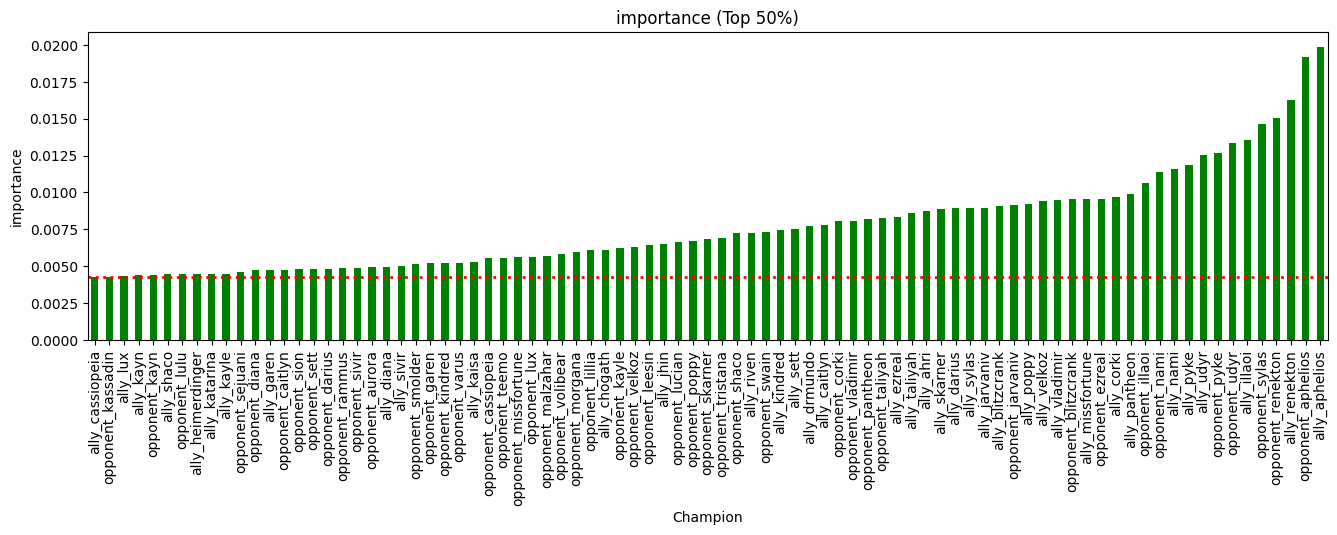

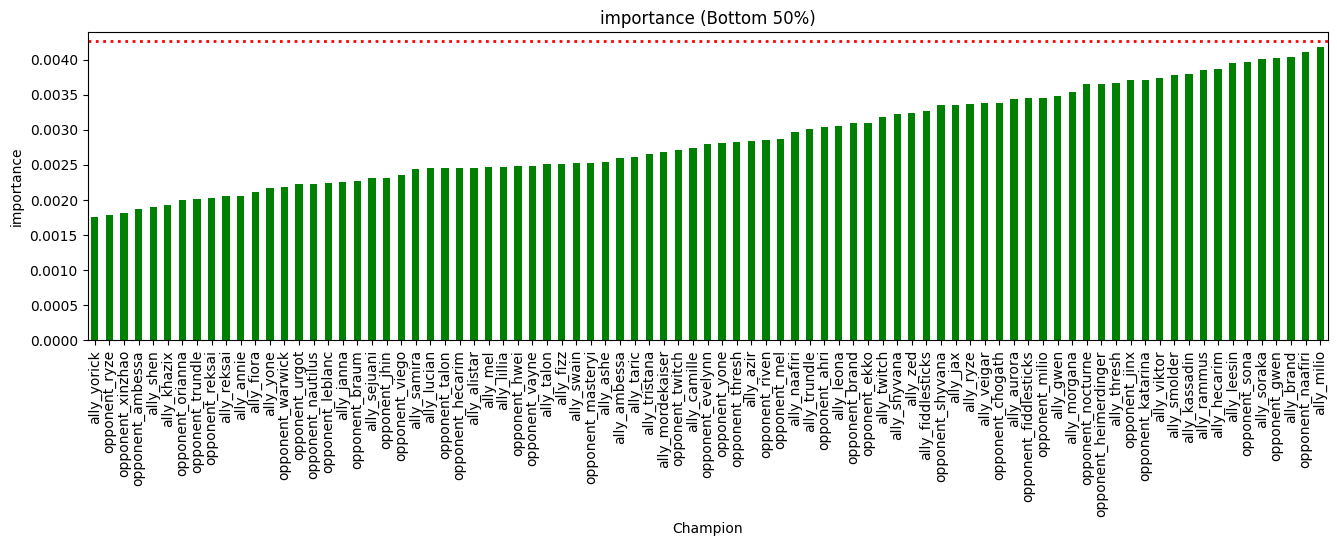

Top 5 Univariate Important Champions: feature
taliyah     4.500000
pyke        4.545455
illaoi      6.400000
jarvaniv    6.545455
aphelios    9.941176
Name: chi2, dtype: float64


In [173]:
gbm_importances = pd.DataFrame(data=best_gbm.feature_importances_, index=X.columns, columns=['importance']).sort_values(by='importance')
feature_imp_plot(gbm_importances[170:], 'importance')
print(f"Top 5 Univariate Important Champions: {high_uni_importance}")

The charts show the top 50% of feature importances based on the gradient boosting model.

The champions identified as high importance by univariate analysis more-less line up with these importances, particularly `aphelios`, which is #1 importance by a significant margin by both univariate analysis and the trained model.

## Random Forest

In [174]:
from sklearn.ensemble import RandomForestClassifier

# base model
rf = RandomForestClassifier(random_state=this_random_state+2)

# parameter search grid
param_grid = {
    'min_samples_leaf': [2, 5, 10],
    'max_depth': [2, 3, 5],
    'n_estimators': [50, 100, 300],
    'bootstrap': [True, False],
    'max_features': [None, 'sqrt', 'log2'],
}

rfgrid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=group_cv,                 
    n_jobs=-1,          
    verbose=2,      
    refit=True         
)
# 4. Fit to your training data
rfgrid.fit(X_train, y_train, groups=groups_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


GridSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(random_state=403), n_jobs=-1,
             param_grid={'bootstrap': [True, False], 'max_depth': [2, 3, 5],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [2, 5, 10],
                         'n_estimators': [50, 100, 300]},
             scoring='roc_auc', verbose=2)

In [175]:
# Inspect the best result
print("BEST AUC    :", rfgrid.best_score_)
print("BEST PARAMS :", rfgrid.best_params_)

# Evaluate on hold-out set
best_rf = rfgrid.best_estimator_
y_pred_proba = best_rf.predict_proba(X_test)[:,1]
y_pred = best_rf.predict(X_test)
y_pred_train = best_rf.predict(X_train)

from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
print("TEST ROC-AUC   :", roc_auc_score(y_test, y_pred_proba))
print("TEST ACCURACY  :", accuracy_score(y_test, y_pred))
print("TRAIN ACCURACY :", accuracy_score(y_train, y_pred_train))
print(classification_report(y_test, y_pred))
rf_eval = ModelEvaluator(best_rf, X, y)
print_eval(rf_eval)

BEST AUC    : 0.5560473372781065
BEST PARAMS : {'bootstrap': True, 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 2, 'n_estimators': 50}
TEST ROC-AUC   : 0.5281632653061225
TEST ACCURACY  : 0.5571428571428572
TRAIN ACCURACY : 0.7138461538461538
              precision    recall  f1-score   support

       False       0.56      0.57      0.56        35
        True       0.56      0.54      0.55        35

    accuracy                           0.56        70
   macro avg       0.56      0.56      0.56        70
weighted avg       0.56      0.56      0.56        70

---- SCORES ----
ACCURACY : 0.549 :: 0.021 std
ROC_AUC  : 0.556 :: 0.04 std
F1       : 0.528 :: 0.056 std
----------------


The optimal random forest model had a reported testing accuracy of **0.56** and a cross-validation mean accuracy of **0.55**. This indicates similar or very slightly better performance than the gradient boosting model. Note the standard deviation of the cross-validation accuracy is half of what it was for gradient boosting, which suggests a more robust model.

### Feature Importance

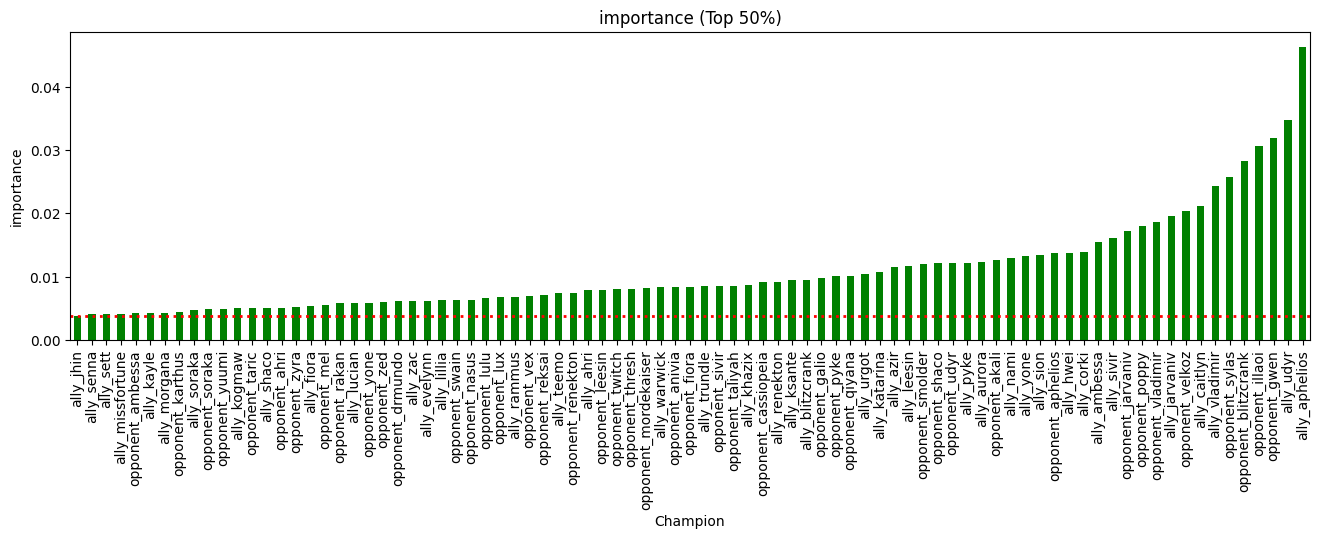

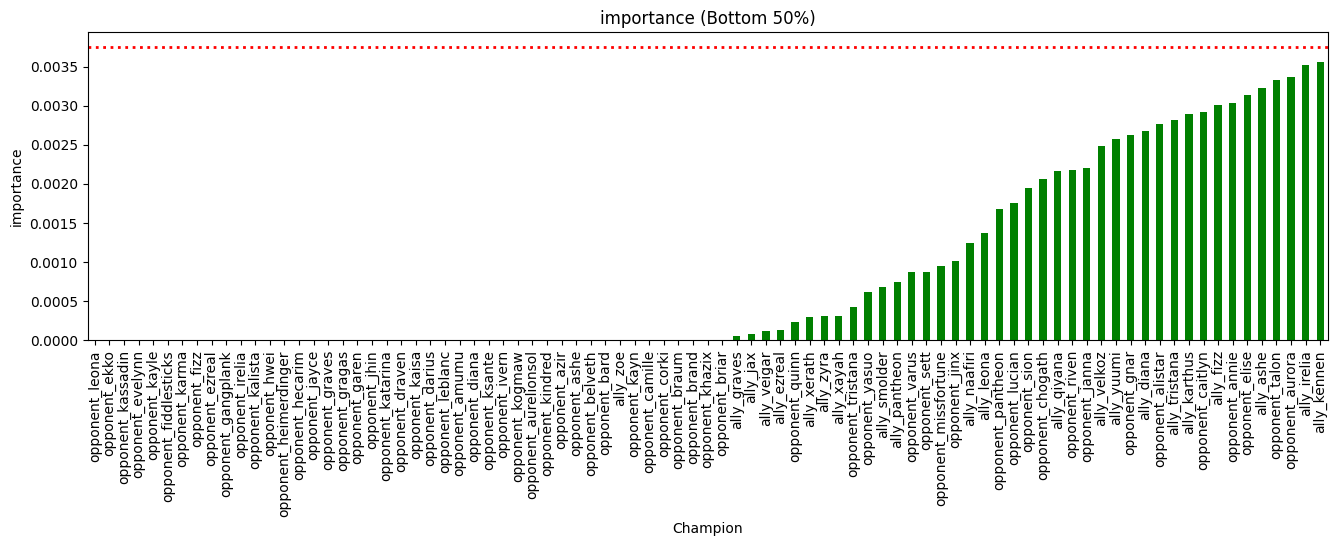

In [176]:
rf_importances = pd.DataFrame(data=best_rf.feature_importances_, index=X.columns, columns=['importance']).sort_values(by='importance')
feature_imp_plot(rf_importances.sort_values(by='importance')[170:], 'importance')

The feature importances of the random forest model differ somewhat significantly than the gradient boosting model. The most notable difference is that the random forest model attributes **more importance** to **less features**, that is to say that it attributes **0** importance to more features than gradient boosting. This suggests that it is a simpler model with **higher bias** and **lower variance**.

# \[ Conclusion \]

## Model Performance

The best model was obtained using the **random forest** tree ensemble method, attaining a cross-validation mean accuracy of **0.55** and a mean roc-auc of **0.56**. Compared to the **gradient boosting** method, random forest generated a **more robust** and simpler model.

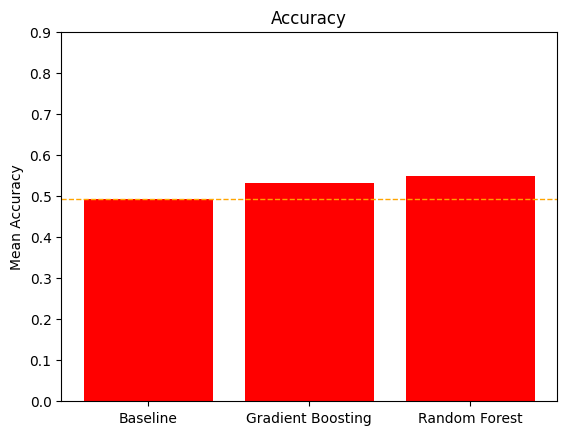

In [190]:
def get_eval(model_eval, key):
    return model_eval.cross_val_score()[f"{key}_mean"]
models = ['Baseline', 'Gradient Boosting', 'Random Forest']
accs = [get_eval(baseline_eval, 'accuracy'), get_eval(gbm_eval, 'accuracy'), get_eval(rf_eval, 'accuracy')]
plt.bar(models, accs, color='red')
plt.axhline(y=accs[0], color='orange', linestyle='--', linewidth=1)
plt.ylabel("Mean Accuracy")
plt.title("Accuracy")
plt.yticks(np.arange(0, 1, 0.1))
plt.show()

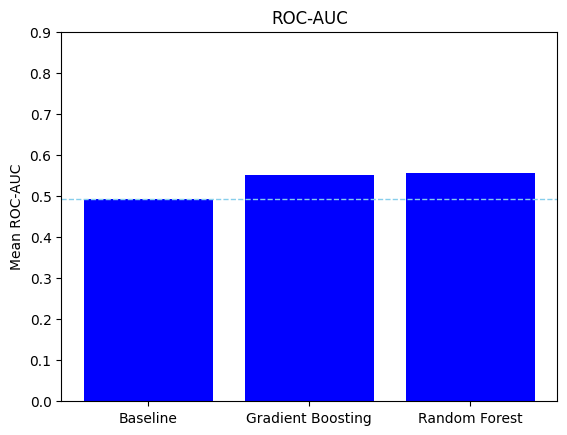

In [191]:
rocs = [get_eval(baseline_eval, 'roc_auc'), get_eval(gbm_eval, 'roc_auc'), get_eval(rf_eval, 'roc_auc')]
plt.bar(models, rocs, color='blue')
plt.axhline(y=accs[0], color='skyblue', linestyle='--', linewidth=1)
plt.ylabel("Mean ROC-AUC")
plt.title("ROC-AUC")
plt.yticks(np.arange(0, 1, 0.1))
plt.show()

While both the gradient boosting and random forest models technically do perform above baseline, the difference is not big enough to be realistically practical, and I would say that either model's performance is **insignicant** at best.

## Primary Areas of Improvement

### Sample Size

The sample size of this dataset is **very low** for the number of features and stated objective and is what I believe to be the **primary bottleneck** of this project. I hypothesize that if the sample size was **>5,000** matches (10,000 rows), a model with a significant (**>= 0.6**) accuracy could be trained with the same decision tree ensemble methods used.

In [194]:
print(f'{int(len(df)/2)} total matches in this dataset.')

360 total matches in this dataset.


### Sample Bias

The algorithm for gathering samples for this dataset was **biased** for matches around my own skill level. Supposing a high-performance model was trained, it may not do well for matches far below/above my own skill level, as different levels of play most likely have **significantly different** champion-composition win trends.

### Model/Training Limitations

The training methods used in this project (and tree-ensemble methods in general) are relatively simple training methods compared to others not covered by this course. I believe, given a sufficiently large dataset, a **neural network** would perform much better than tree-ensemble methods, considering it's strength in capturing **complex non-linear relationships**. With that being said, neural networks often need a very large dataset in order to be effectively trained.

## Final Statements

### Objective

The objective of this project was to create a model that can predict the outcome of a League of Legends match based only on each team's champions.

I **do not** feel like this objective was met. The highest performing model had cross validation accuracy of **0.55**, which is not significantly higher than baseline.

I learned alot from doing this project regardless of it's success.

### Better Practices

If I were to do this project again, I would:
- Make more time to collect match data, possibly with a more efficient algorithm to minimize API calls.
- Use multiple different players of different skill levels as "collection roots" to gather match data from many different skill levels.
- Perhaps try and train a basic neural network if the dataset is large enough.